# Librerias

In [175]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from pathlib import Path
import squarify

# Cargar el Dat Set

In [144]:

# NO MODIFICAR LAS SIGUIENTES 2 LÍNEAS, YA QUE MUESTRAN MEJOR EL DATAFRAME AL HACER "PRINT" O "HEAD"
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.options.display.float_format = '{:,.0f}'.format

In [145]:
# Traigamos el dataset y separemos las variables independientes de la variable dependiente (target)
ruta = Path.cwd() / "05.02.2026 EXTRACCION VIVIENDA FR.xlsx"

df = pd.read_excel(ruta)

X = df.drop(columns=["Precio"])
y = df["Precio"]

In [146]:
df = pd.concat([X, y], axis=1)

display(df.head(10))

,ID,Barrio,Tipo de Inmueble,Estado,Antigüedad,Área Construida (m2),Área Privada (m2),Estrato,Baños,Habitaciones,Parqueaderos,Piso N°,URL,Precio
0,193673918,Boston,Apartamento,Usado,NaN,60,60,4,2,3,0,4,https://wwwfincaraizcomco/apartamento-en-arrie...,1700000
1,193622107,Manrique,Casa,Usado,16 a 30 años,130,130,2,2,3,0,3,https://wwwfincaraizcomco/casa-en-arriendo-en-...,2200000
2,193621915,Robledo,Apartamento,Usado,más de 30 años,52,52,3,1,3,0,12,https://wwwfincaraizcomco/apartamento-en-arrie...,1400000
3,193550885,El Poblado,Apartamento,Usado,9 a 15 años,95,95,6,2,3,2,10,https://wwwfincaraizcomco/apartamento-en-arrie...,5100000
4,193459016,La salle,Apartamento,Usado,16 a 30 años,114,114,5,2,3,1,NaN,https://wwwfincaraizcomco/apartamento-en-arrie...,4200000
5,193378521,Las palmas,Apartamento,Usado,16 a 30 años,100,100,5,3,3,1,7,https://wwwfincaraizcomco/apartamento-en-arrie...,5600000
6,193373889,San diego,Apartamento,Usado,NaN,80,80,5,2,3,1,18,https://wwwfincaraizcomco/apartamento-en-arrie...,4000000
7,193320770,Las palmas,Apartamento,Usado,1 a 8 años,64,64,6,2,2,1,7,https://wwwfincaraizcomco/apartamento-en-arrie...,3500000
8,193150810,Manrique,Apartamento,Usado,16 a 30 años,40,40,2,1,2,0,1,https://wwwfincaraizcomco/apartamento-en-arrie...,550000
9,192905174,Guayabal,Apartamento,Usado,NaN,70,70,5,2,2,1,14,https://wwwfincaraizcomco/apartamento-en-arrie...,3700000


# Limpieza e imputacion de datos

In [147]:
 df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5628 entries, 0 to 5627
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    5628 non-null   int64  
 1   Barrio                5628 non-null   str    
 2   Tipo de Inmueble      5628 non-null   str    
 3   Estado                5628 non-null   str    
 4   Antigüedad            4228 non-null   str    
 5   Área Construida (m2)  5505 non-null   float64
 6   Área Privada (m2)     5505 non-null   float64
 7   Estrato               5576 non-null   float64
 8   Baños                 5586 non-null   float64
 9   Habitaciones          5536 non-null   float64
 10  Parqueaderos          5628 non-null   int64  
 11  Piso N°               2934 non-null   float64
 12  URL                   5628 non-null   str    
 13  Precio                5628 non-null   int64  
dtypes: float64(6), int64(3), str(5)
memory usage: 615.7 KB


In [148]:
# Cambiar de tipo de variable de ID a string
df["ID"] = df["ID"].astype(str)

In [149]:
# Remplazar las variables numéricas faltantes utilizando KNNImputer

cols_int = ["Estrato", "Baños", "Habitaciones", "Piso N°"]
cols_float = ["Área Construida (m2)", "Área Privada (m2)"]
cols_all = cols_int + cols_float

imputer = KNNImputer(n_neighbors=5)
df[cols_all] = imputer.fit_transform(df[cols_all])

# cambiamos de tipo de variable a int y float
df[cols_int] = df[cols_int].astype(int)
# cambiamos de tipo de variable a float
df[cols_float] = df[cols_float].astype(float)

In [150]:
# Reemplazar los valores faltantes en la columna "Antigüedad" con "Desconocido"
df["Antigüedad"] = df["Antigüedad"].fillna("Desconocido")

In [151]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5628 entries, 0 to 5627
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    5628 non-null   str    
 1   Barrio                5628 non-null   str    
 2   Tipo de Inmueble      5628 non-null   str    
 3   Estado                5628 non-null   str    
 4   Antigüedad            5628 non-null   str    
 5   Área Construida (m2)  5628 non-null   float64
 6   Área Privada (m2)     5628 non-null   float64
 7   Estrato               5628 non-null   int64  
 8   Baños                 5628 non-null   int64  
 9   Habitaciones          5628 non-null   int64  
 10  Parqueaderos          5628 non-null   int64  
 11  Piso N°               5628 non-null   int64  
 12  URL                   5628 non-null   str    
 13  Precio                5628 non-null   int64  
dtypes: float64(2), int64(6), str(6)
memory usage: 615.7 KB


In [152]:
display(df.head(10))

,ID,Barrio,Tipo de Inmueble,Estado,Antigüedad,Área Construida (m2),Área Privada (m2),Estrato,Baños,Habitaciones,Parqueaderos,Piso N°,URL,Precio
0,193673918,Boston,Apartamento,Usado,Desconocido,60,60,4,2,3,0,4,https://wwwfincaraizcomco/apartamento-en-arrie...,1700000
1,193622107,Manrique,Casa,Usado,16 a 30 años,130,130,2,2,3,0,3,https://wwwfincaraizcomco/casa-en-arriendo-en-...,2200000
2,193621915,Robledo,Apartamento,Usado,más de 30 años,52,52,3,1,3,0,12,https://wwwfincaraizcomco/apartamento-en-arrie...,1400000
3,193550885,El Poblado,Apartamento,Usado,9 a 15 años,95,95,6,2,3,2,10,https://wwwfincaraizcomco/apartamento-en-arrie...,5100000
4,193459016,La salle,Apartamento,Usado,16 a 30 años,114,114,5,2,3,1,4,https://wwwfincaraizcomco/apartamento-en-arrie...,4200000
5,193378521,Las palmas,Apartamento,Usado,16 a 30 años,100,100,5,3,3,1,7,https://wwwfincaraizcomco/apartamento-en-arrie...,5600000
6,193373889,San diego,Apartamento,Usado,Desconocido,80,80,5,2,3,1,18,https://wwwfincaraizcomco/apartamento-en-arrie...,4000000
7,193320770,Las palmas,Apartamento,Usado,1 a 8 años,64,64,6,2,2,1,7,https://wwwfincaraizcomco/apartamento-en-arrie...,3500000
8,193150810,Manrique,Apartamento,Usado,16 a 30 años,40,40,2,1,2,0,1,https://wwwfincaraizcomco/apartamento-en-arrie...,550000
9,192905174,Guayabal,Apartamento,Usado,Desconocido,70,70,5,2,2,1,14,https://wwwfincaraizcomco/apartamento-en-arrie...,3700000


In [153]:
df.describe()

,Área Construida (m2),Área Privada (m2),Estrato,Baños,Habitaciones,Parqueaderos,Piso N°,Precio
count,"5,628","5,628","5,628","5,628","5,628","5,628","5,628","5,628"
mean,411,412,4,2,3,1,6,"5,120,721"
std,"2,226","2,176",1,1,1,3,5,"19,181,197"
min,1,1,1,1,1,0,1,"450,000"
25%,60,60,4,2,2,0,2,"2,350,000"
50%,80,80,4,2,3,1,5,"3,500,000"
75%,120,120,5,3,3,1,8,"5,000,000"
max,"55,200","55,200",6,20,25,127,97,"750,000,000"


In [154]:
df["Estado"].value_counts()

Estado
Usado               4977
Buen estado          396
Nuevo                161
Excelente estado      94
Name: count, dtype: int64

In [155]:
df["Tipo de Inmueble"].value_counts()

Tipo de Inmueble
Apartamento      4144
Casa              856
Apartaestudio     628
Name: count, dtype: int64

In [156]:
df["Antigüedad"].value_counts()

Antigüedad
Desconocido       1400
1 a 8 años        1305
16 a 30 años      1246
9 a 15 años        743
más de 30 años     522
menor a 1 año      412
Name: count, dtype: int64

# Cruce con respecto al precio

In [157]:
df.groupby("Estrato")["Precio"].describe()

,count,mean,std,min,25%,50%,75%,max
Estrato,,,,,,,,
1,12,"2,129,167","1,501,457","450,000","1,087,500","1,640,000","2,525,000","5,200,000"
2,127,"1,611,756","1,171,286","500,000","1,010,000","1,300,000","1,725,000","9,600,000"
3,"1,036","2,584,738","11,244,582","480,000","1,350,000","1,800,000","2,500,000","322,000,000"
4,"1,651","4,391,141","24,815,443","800,000","2,300,000","2,900,000","3,600,000","750,000,000"
5,"1,562","5,166,202","15,668,188","700,000","3,200,000","3,950,000","5,200,000","610,000,000"
6,"1,240","8,541,942","20,411,217","1,900,000","4,300,000","5,900,000","8,500,000","680,000,000"


In [158]:
df.groupby("Antigüedad")["Precio"].describe()

,count,mean,std,min,25%,50%,75%,max
Antigüedad,,,,,,,,
1 a 8 años,"1,305","4,828,463","5,972,546","450,000","2,500,000","3,600,000","5,300,000","116,000,000"
16 a 30 años,"1,246","4,635,242","6,682,852","550,000","2,362,500","3,405,000","4,776,250","160,000,000"
9 a 15 años,743,"4,719,810","4,202,466","550,000","2,575,000","3,800,000","5,500,000","60,000,000"
Desconocido,"1,400","6,603,837","37,185,775","500,000","2,287,500","3,300,000","4,700,000","750,000,000"
menor a 1 año,412,"3,842,633","3,284,419","920,000","2,275,000","3,000,000","4,200,000","38,000,000"
más de 30 años,522,"4,611,895","4,738,202","480,000","2,062,500","3,200,000","5,200,000","45,000,000"


In [159]:
df.groupby("Tipo de Inmueble")["Precio"].describe()

,count,mean,std,min,25%,50%,75%,max
Tipo de Inmueble,,,,,,,,
Apartaestudio,628,"2,303,973","2,493,760","480,000","1,250,000","1,700,000","2,500,000","35,000,000"
Apartamento,"4,144","4,967,437","21,845,160","450,000","2,543,000","3,500,000","4,800,000","750,000,000"
Casa,856,"7,929,282","9,518,205","750,000","3,000,000","4,565,000","9,500,000","116,000,000"


In [161]:
df.groupby("Habitaciones")["Precio"].describe()

,count,mean,std,min,25%,50%,75%,max
Habitaciones,,,,,,,,
1,800,"3,213,745","24,053,889","480,000","1,300,000","1,800,000","2,800,000","680,000,000"
2,"1,656","4,495,293","22,893,564","450,000","2,150,000","3,000,000","4,100,000","750,000,000"
3,"2,367","4,968,880","16,616,163","800,000","2,800,000","3,700,000","5,200,000","610,000,000"
4,495,"6,994,768","6,382,696","1,140,000","3,400,000","4,650,000","8,000,000","50,000,000"
5,161,"7,799,286","6,343,504","1,600,000","3,980,000","5,500,000","9,500,000","40,000,000"
6,60,"11,353,333","12,264,375","2,000,000","4,500,000","7,250,000","13,275,000","60,000,000"
7,32,"15,009,375","10,164,212","4,000,000","6,950,000","11,450,000","22,000,000","35,000,000"
8,21,"18,209,524","23,170,540","3,000,000","8,500,000","15,800,000","16,900,000","116,000,000"
9,9,"10,329,444","5,484,187","3,500,000","7,000,000","9,800,000","12,000,000","20,000,000"


In [162]:
desc = df.groupby("Barrio")["Precio"].describe()

# Mostrar los 20 barrios con más registros
desc.sort_values("count", ascending=False).head(50)

,count,mean,std,min,25%,50%,75%,max
Barrio,,,,,,,,
El Poblado,966,"6,587,076","5,380,023","1,600,000","3,800,000","5,000,000","7,400,000","67,000,000"
Laureles,599,"4,483,214","3,339,639","750,000","2,700,000","3,600,000","5,000,000","35,000,000"
Belén,287,"6,211,404","44,146,536","900,000","2,500,000","3,050,000","4,000,000","750,000,000"
Calasanz,257,"2,937,276","1,943,759","850,000","2,300,000","2,700,000","3,250,000","30,000,000"
Las palmas,165,"7,415,333","8,297,288","480,000","3,500,000","4,400,000","7,100,000","50,000,000"
Loma del Indio,158,"4,671,703","5,771,272","2,000,000","3,000,000","3,600,000","4,500,000","60,000,000"
Robledo,157,"2,019,255","1,444,335","750,000","1,350,000","1,650,000","2,200,000","15,000,000"
Buenos aires,139,"1,918,633","815,735","690,000","1,375,000","1,750,000","2,200,000","5,000,000"
San diego,105,"3,868,762","1,760,122","1,100,000","3,100,000","3,600,000","4,100,000","17,000,000"


In [163]:
desc = df.groupby("Área Construida (m2)")["Precio"].describe()

# Mostrar los 20 barrios con más registros
desc.sort_values("count", ascending=False).head(50)

,count,mean,std,min,25%,50%,75%,max
Área Construida (m2),,,,,,,,
70,265,"3,175,532","1,188,170","870,000","2,500,000","3,000,000","3,600,000","9,000,000"
60,209,"2,546,234","839,658","1,100,000","1,900,000","2,500,000","3,000,000","5,400,000"
80,196,"3,752,245","4,724,460","750,000","2,600,000","3,200,000","4,000,000","67,000,000"
65,167,"2,756,198","919,651","800,000","2,100,000","2,700,000","3,400,000","6,700,000"
75,153,"3,564,026","1,251,369","850,000","2,800,000","3,300,000","4,000,000","7,500,000"
90,149,"4,929,416","12,876,696","1,400,000","2,700,000","3,700,000","4,800,000","160,000,000"
50,139,"2,170,712","927,175","950,000","1,600,000","2,000,000","2,500,000","6,500,000"
100,134,"4,302,134","1,816,916","1,600,000","3,125,000","4,000,000","5,200,000","12,000,000"
55,130,"2,322,946","879,339","1,000,000","1,650,000","2,100,000","2,700,000","5,500,000"


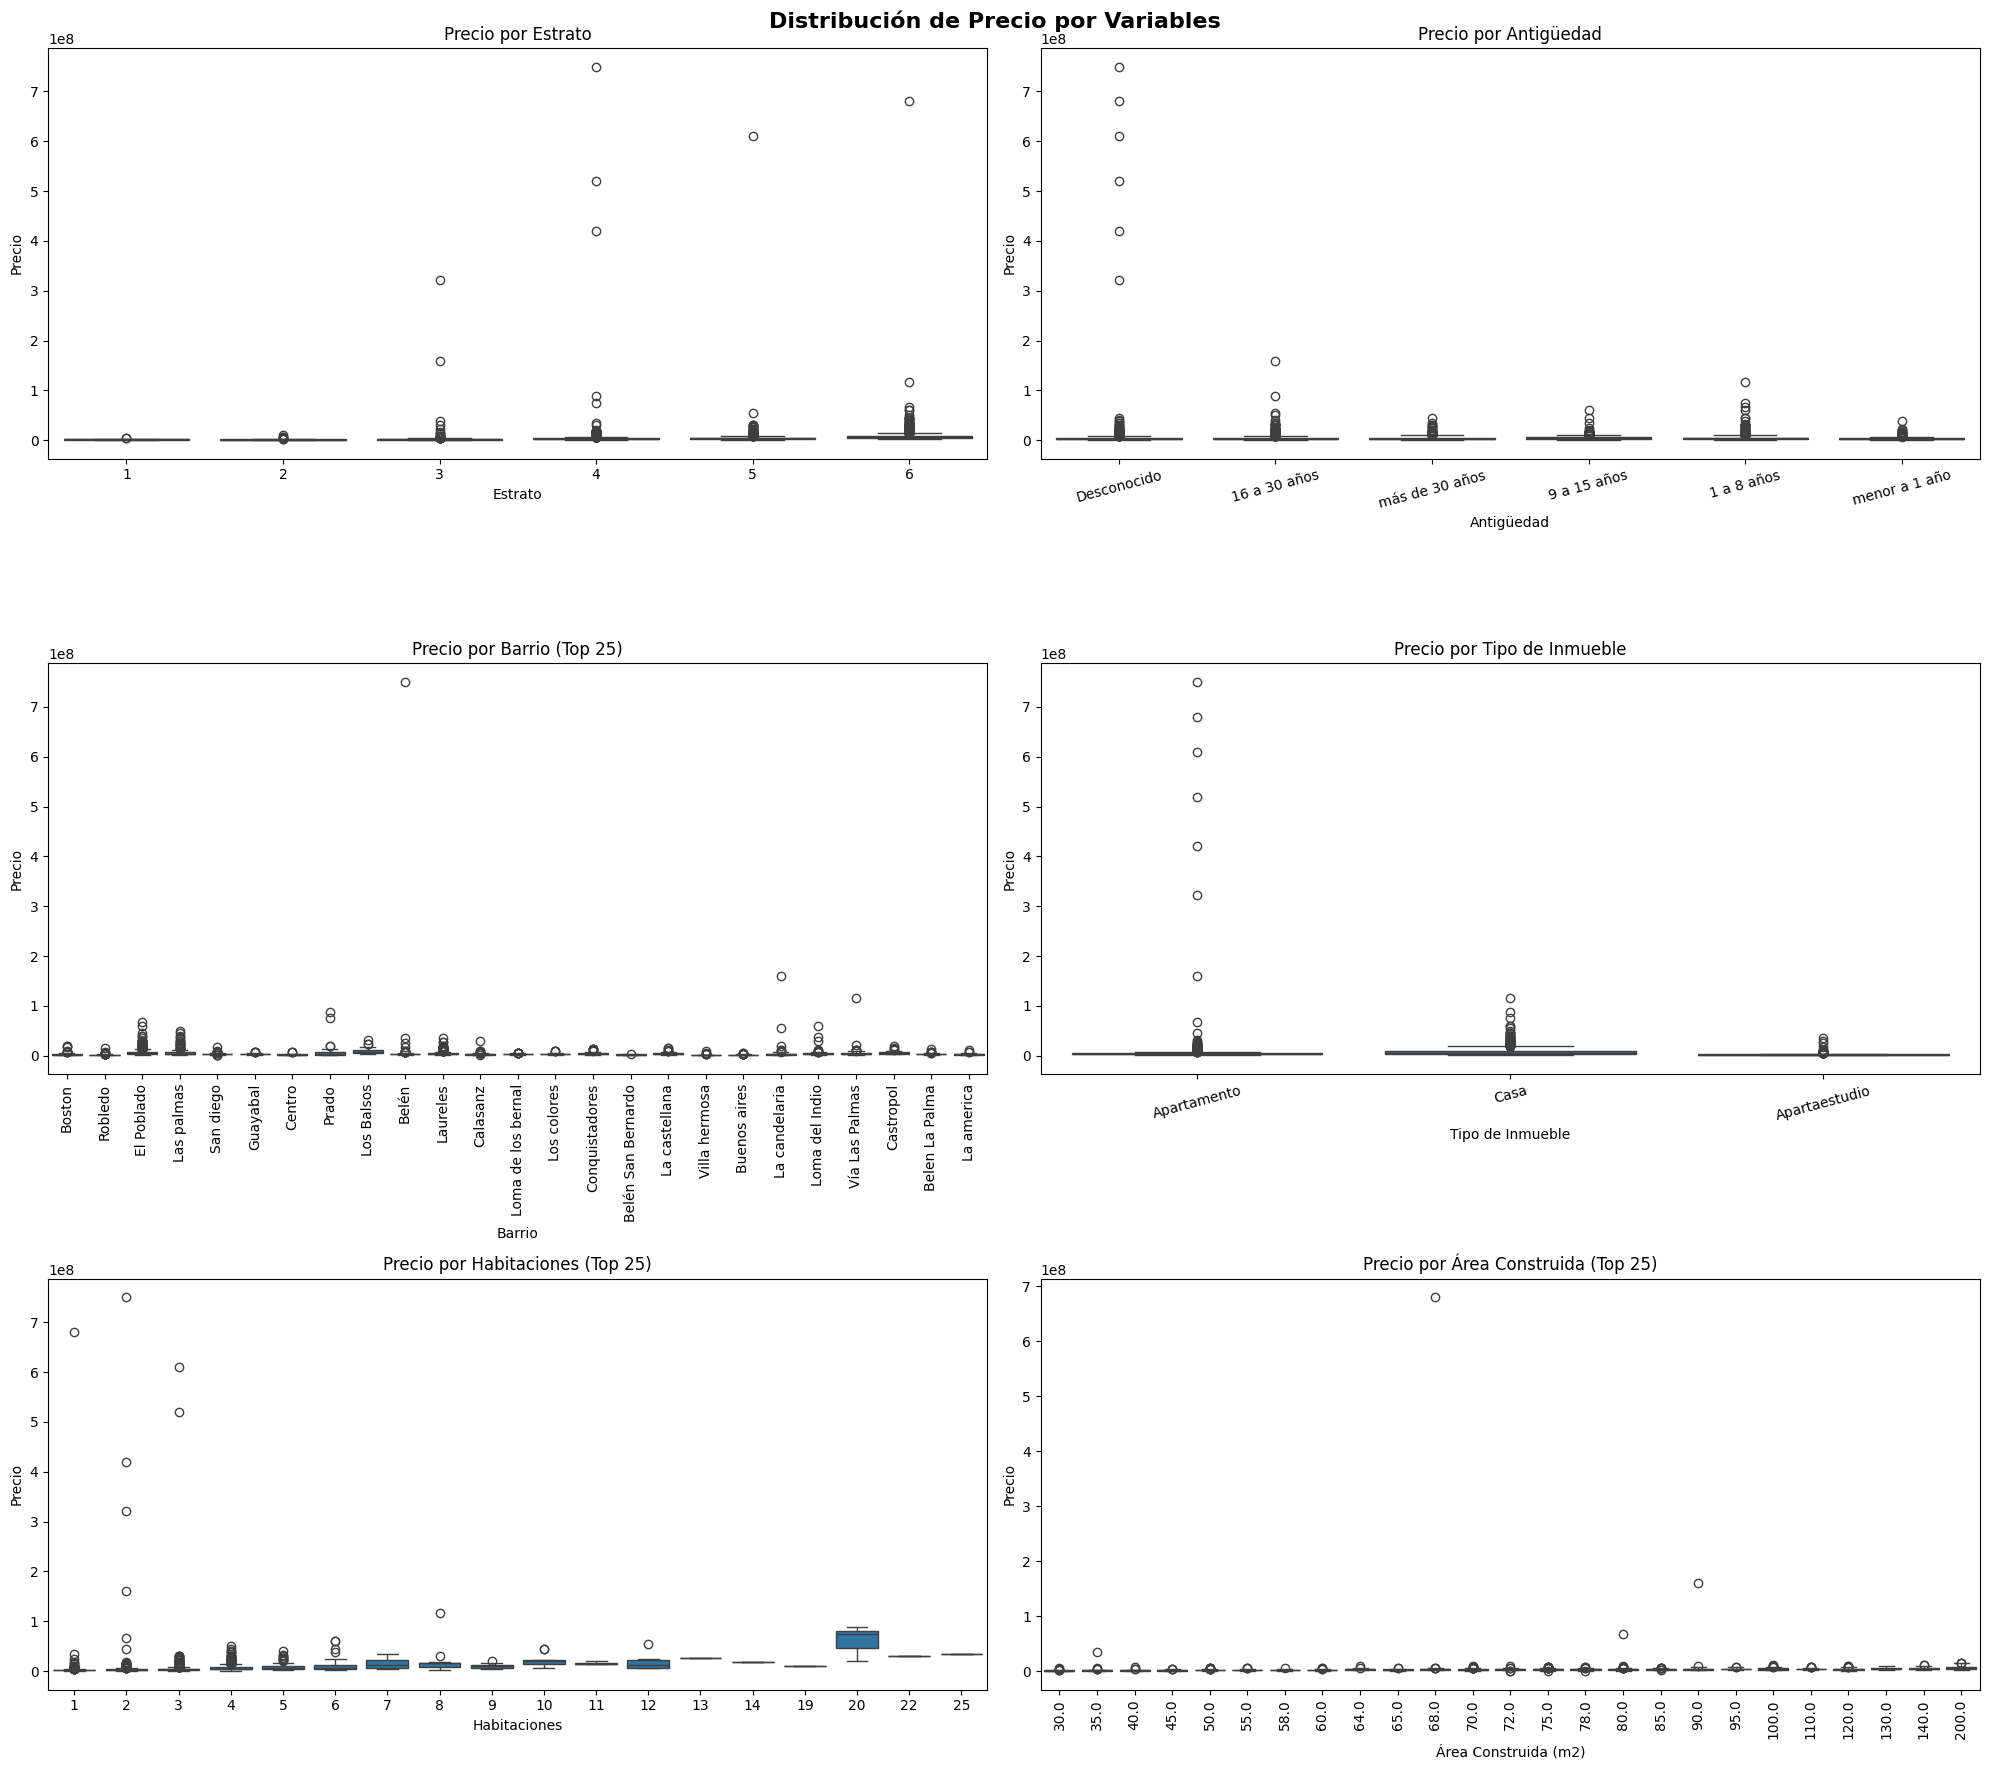

In [164]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 25 de cada variable
top_barrios = df["Barrio"].value_counts().head(25).index
top_habitaciones = df["Habitaciones"].value_counts().head(25).index
top_area = df["Área Construida (m2)"].value_counts().head(25).index

# Filtros
df_barrio = df[df["Barrio"].isin(top_barrios)]
df_hab = df[df["Habitaciones"].isin(top_habitaciones)]
df_area = df[df["Área Construida (m2)"].isin(top_area)]

# Tablero
fig, axes = plt.subplots(3, 2, figsize=(20, 18))
fig.suptitle("Distribución de Precio por Variables", fontsize=16, fontweight="bold")

# 1. Estrato
sns.boxplot(data=df, x="Estrato", y="Precio", ax=axes[0, 0])
axes[0, 0].set_title("Precio por Estrato")

# 2. Antigüedad
sns.boxplot(data=df, x="Antigüedad", y="Precio", ax=axes[0, 1])
axes[0, 1].set_title("Precio por Antigüedad")
axes[0, 1].tick_params(axis="x", rotation=15)

# 3. Barrio (Top 25)
sns.boxplot(data=df_barrio, x="Barrio", y="Precio", ax=axes[1, 0])
axes[1, 0].set_title("Precio por Barrio (Top 25)")
axes[1, 0].tick_params(axis="x", rotation=90)

# 4. Tipo de Inmueble
sns.boxplot(data=df, x="Tipo de Inmueble", y="Precio", ax=axes[1, 1])
axes[1, 1].set_title("Precio por Tipo de Inmueble")
axes[1, 1].tick_params(axis="x", rotation=15)

# 5. Habitaciones (Top 25)
sns.boxplot(data=df_hab, x="Habitaciones", y="Precio", ax=axes[2, 0])
axes[2, 0].set_title("Precio por Habitaciones (Top 25)")

# 6. Área Construida (Top 25)
sns.boxplot(data=df_area, x="Área Construida (m2)", y="Precio", ax=axes[2, 1])
axes[2, 1].set_title("Precio por Área Construida (Top 25)")
axes[2, 1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

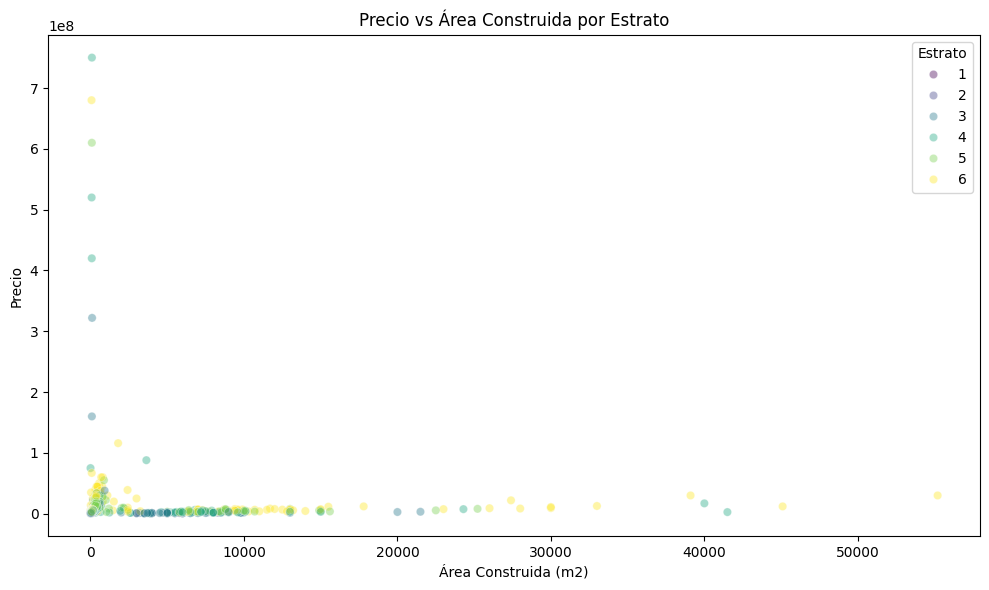

In [173]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Área Construida (m2)", y="Precio", hue="Estrato", alpha=0.4, palette="viridis")

plt.title("Precio vs Área Construida por Estrato")
plt.xlabel("Área Construida (m2)")
plt.ylabel("Precio")
plt.legend(title="Estrato")
plt.tight_layout()
plt.show()

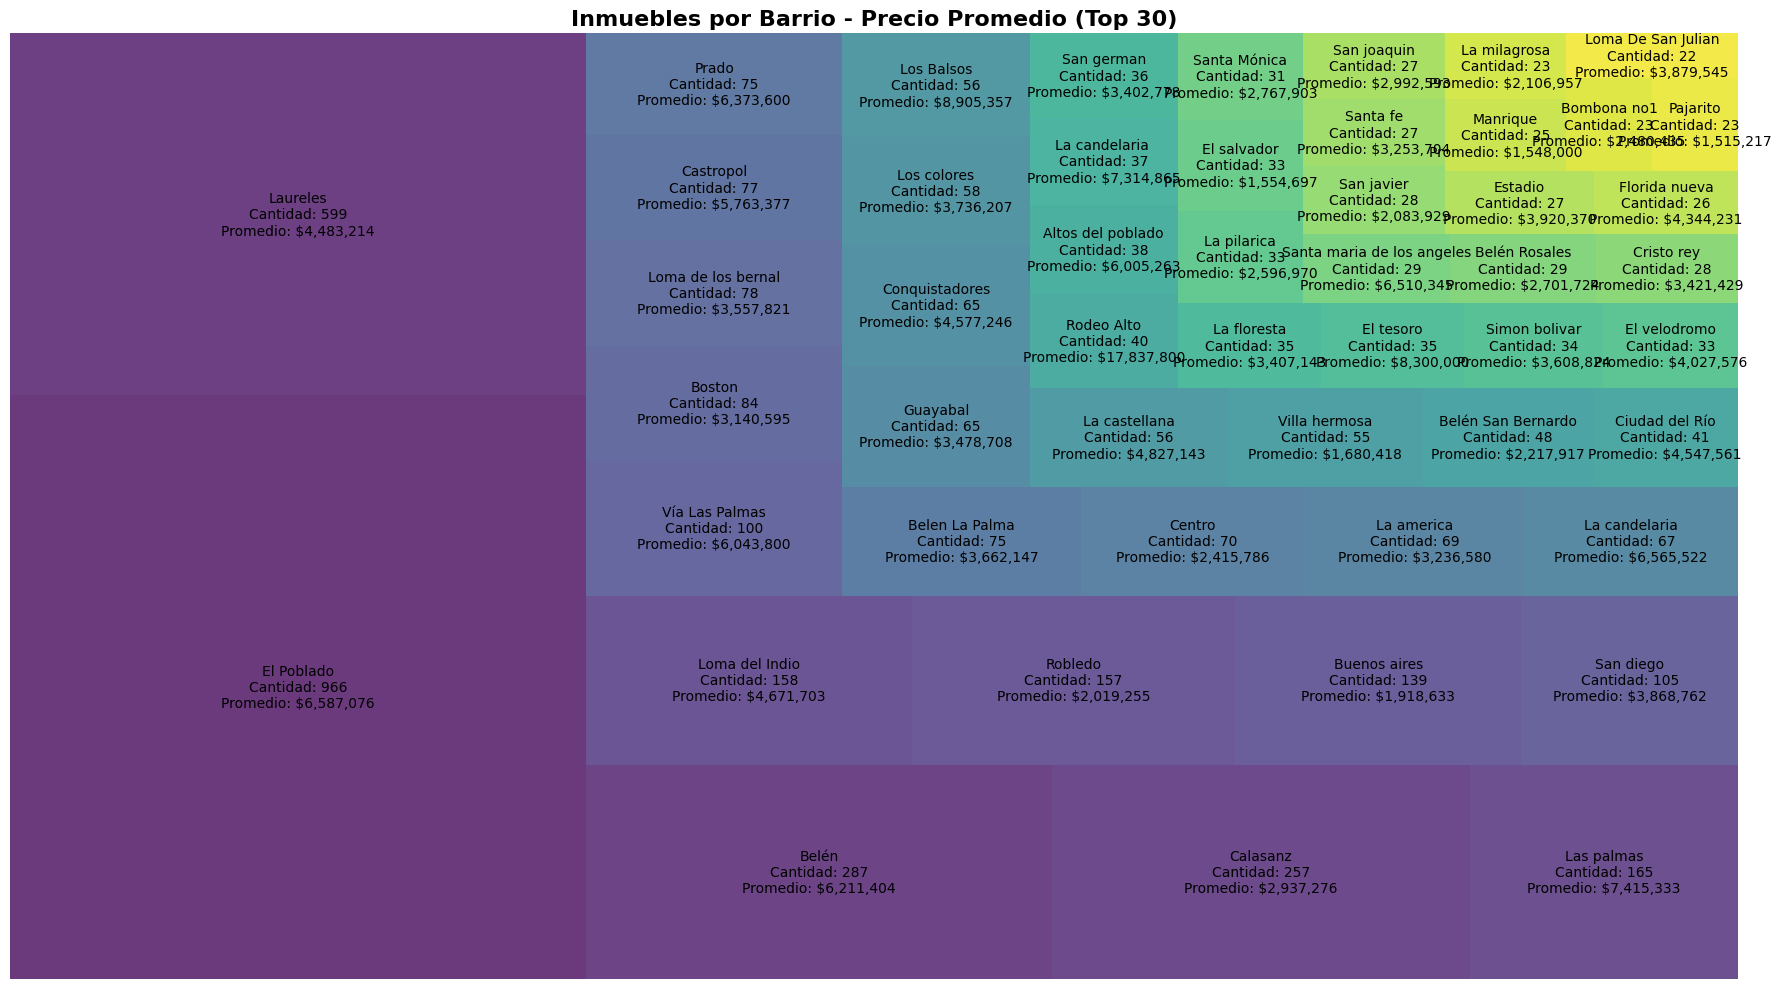

In [180]:
# Cantidad e inmuebles y precio promedio por barrio
df_tree = df.groupby("Barrio").agg(
    cantidad=("Precio", "count"),
    precio_promedio=("Precio", "mean")
).sort_values("cantidad", ascending=False).head(50).reset_index()

# Graficar
plt.figure(figsize=(18, 10))
squarify.plot(
    sizes=df_tree["cantidad"],  # Tamaño = cantidad de inmuebles
    label=[f'{b}\nCantidad: {c}\nPromedio: ${p:,.0f}' 
           for b, c, p in zip(df_tree["Barrio"], df_tree["cantidad"], df_tree["precio_promedio"])],
    alpha=0.8,
    color=sns.color_palette("viridis", len(df_tree))
)

plt.title("Inmuebles por Barrio - Precio Promedio (Top 30)", fontsize=16, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()